In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, EllipticalAperture, EllipticalAnnulus
from astropy.nddata import Cutout2D
from matplotlib.patches import Ellipse
from astropy.table import Table, vstack, Column, unique
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from matplotlib_scalebar.scalebar import ScaleBar

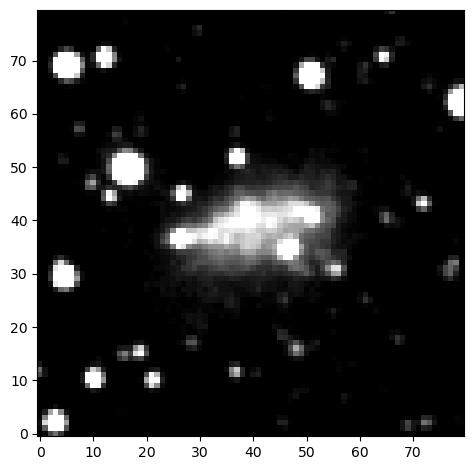

In [3]:
hdu = fits.open('LeoA_Dwarf.fits')
data = hdu[0].data
header = hdu[0].header

cmap = plt.cm.Greys_r

position = (466.26842, 1352.2418)
size = (80, 80)
cutout = Cutout2D(data, position, size)

minim = np.percentile(cutout.data, 70)
maxim = np.percentile(cutout.data, 97)

plt.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
plt.tight_layout()

plt.show()

In [4]:
# a = 172.5" / 7.8"/pix = 22.1
# b = 105.225" / 7.8"/pix = 13.5
# angle was just a guesstimate lol

position = (40, 40)
a, b, theta = 22.1, 13.5, np.radians(15)
aperture = EllipticalAperture(position, a, b, theta)

aper_overlay = Ellipse(
    xy=position, 
    width=a, 
    height=b,
    angle=np.degrees(theta),
    edgecolor='red',
    facecolor='none',
    linewidth=2,
    alpha=1.0
)

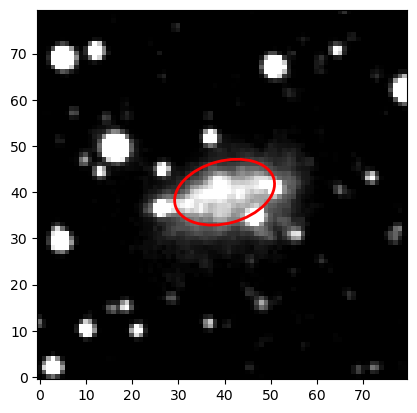

In [5]:
fig, ax = plt.subplots()
ax.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
ax.add_patch(aper_overlay)
plt.show()

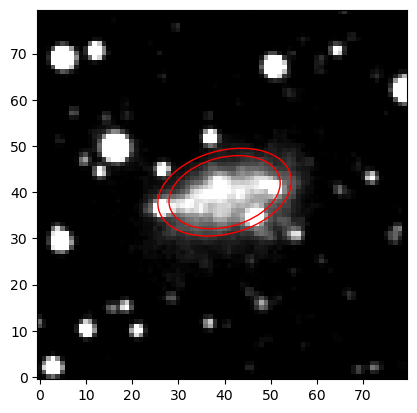

In [18]:
# annulus
a_in = 15
a_out = 18
b_in = 24.6
b_out = b_in*(a_out/a_in)
theta = 105

annulus = EllipticalAnnulus(position, a_in, a_out, b_out, b_in, theta)

ann_overlay_in=Ellipse(
    xy=position,
    width=a_in,
    height=b_in,
    angle=theta,
    edgecolor='red',   
    facecolor='none', 
    linewidth=1,       
    alpha=1.0          
)

ann_overlay_out=Ellipse(
    xy=position,
    width=a_out,
    height=b_out,
    angle=theta,
    edgecolor='red',   
    facecolor='none', 
    linewidth=1,       
    alpha=1.0          
)

fig, ax = plt.subplots()
ax.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')

ax.add_patch(ann_overlay_in)
ax.add_patch(ann_overlay_out)
plt.show()

In [7]:
zeroPoint = header['ZEROPT']
print(zeroPoint)

23.04141709211252


In [8]:
def mag_calculation(cutout, aperture, annulus, zp):
    phot_table = aperture_photometry(cutout.data, [aperture, annulus])
    bkg_mean = phot_table['aperture_sum_1'] / annulus.area
    net_flux = phot_table['aperture_sum_0'] - (bkg_mean * aperture.area)
    magnitude = (-2.5 * np.log10(net_flux)) + zp
    gal_signal=net_flux
    bkg_error=np.sqrt(bkg_mean*aperture.area)
    #the counting statistics error is just the square root of the raw counts in the aperture
    CS_error=np.sqrt(phot_table['aperture_sum_0'])
    #Now, add these in quadrature
    net_error=np.sqrt((bkg_error**2) + (CS_error**2))
    SNR= gal_signal/net_error
    mag_err=1.086/SNR
    print(f"Magnitude: {magnitude[0]} +/- {mag_err[0]}")
    return mag_err[0], magnitude[0]

In [9]:
error, mag = mag_calculation(cutout, aperture, annulus, zeroPoint)

Magnitude: 10.607277188386604 +/- 0.007066709353730977


In [10]:
gal_m = mag
A = a * 7.8
B = b * 7.8
a = A/2
b = B/2

gal_A = np.pi * (A/2) * (B/2)

gal_SB = gal_m + (2.5 * np.log10(gal_A))

print(gal_SB)

20.99229001070473


In [11]:
sigma_m = error
sigma_a = 0.05 * 172.5
sigma_b = 0.05 * 105.225

sigma_A = np.sqrt((np.pi * b * sigma_a)**2 + (np.pi * a * sigma_b)**2)

sigma_SB = np.sqrt((sigma_m)**2 + ((sigma_A * 2.5)/(gal_A * np.log(10)))**2)

print(gal_SB, ' +/- ', sigma_SB)

20.99229001070473  +/-  0.15370761946925823


In [12]:
# ask about np.log(10) in cell above fifth line
# ask about LeoA Star Data fits file like we did for Kamino so I can make the graph
# ask about size of aperture - should be bigger? Magnitude calculation is lower than other measurements by other people

In [13]:
Star_Data=Table.read('Kamino_Star_Data.fits')
print(Star_Data)

      gmags              radii       
       mag                           
------------------ ------------------
 18.42687797452318 38.284271999999994
 18.99677797452318          28.549248
 18.99677797452318          28.549248
 16.23307797452318 30.193800000000003
 16.23307797452318 30.193800000000003
 17.62427797452318  61.83964799999999
17.234177974523178  77.84555999999999
 18.32297797452318 35.092200000000005
 17.75607797452318 60.169200000000004
               ...                ...
 17.60257797452318 33.742799999999995
16.993177974523178 39.666900000000005
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 17.26567797452318  70.60419599999999
 17.26567797452318  70.60419599999999
 19.03037797452318             28.119
 14.68977797452318 40.240199999999994
Length = 28612 rows


In [14]:
star_mags=Star_Data['gmags']
star_rads=Star_Data['radii']

star_SBs=star_mags+(2.5*np.log10(np.pi*star_rads*star_rads))

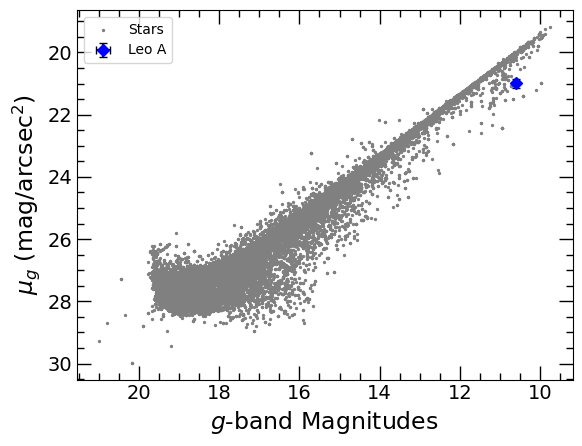

In [16]:
compass = AnchoredDirectionArrows(plt.gca().transAxes, 'E', 'N', loc="lower right", color="red", 
                                  aspect_ratio=-1, back_length=0., length=-0.11, sep_y=0.03, 
                                  sep_x=-0.03)

scalebar1 = ScaleBar(dx=0.0021667, dimension='angle', units="deg", location="lower left", frameon=False, color='red', pad=0.2)


plt.scatter(star_mags,star_SBs, color='grey', s=2, label="Stars")
# plt.scatter(gal_m,gal_SB, color='blue', s=20, marker='D')
plt.errorbar(gal_m,gal_SB, yerr=sigma_SB, xerr=sigma_m, fmt='D', color='blue', ecolor='black', capsize=3, label="Leo A")
compass = AnchoredDirectionArrows(plt.gca().transAxes, 'E', 'N', loc="lower right", color="red", 
                                  aspect_ratio=-1, back_length=0., length=-0.11, sep_y=0.03, 
                                  sep_x=-0.03)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
#plt.gca().add_artist(compass)
#plt.gca().add_artist(scalebar1)

#Add x and y axes!
plt.xlabel(r"$g$-band Magnitudes", fontsize=17)
plt.ylabel(r"$\mu_g$ (mag/arcsec$^2$)", fontsize=17)
plt.minorticks_on()
plt.tick_params(which='both',direction="in", right=True, top=True)
plt.tick_params(which='major',direction="in", right=True, top=True, length=10, width=1, labelsize=14)
plt.tick_params(which='minor',direction="in", right=True, top=True, length=5, width=1)

plt.legend()
plt.savefig("SB_vs_G_plot.png", dpi=600, bbox_inches='tight')